In [4]:
import os
import torch

print(f"GPU : {torch.cuda.get_device_name(0)}")
print(f"CUDA: {torch.cuda.is_available()}")

base = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset"
print("\nСтруктура датасета:")
for item in os.listdir(base):
    print(" ", item)

GPU : Tesla T4
CUDA: True

Структура датасета:
  New Plant Diseases Dataset(Augmented)
  new plant diseases dataset(augmented)
  test


In [5]:
import os
from pathlib import Path

BASE = Path("/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset")
TRAIN_DIR = VALID_DIR = TEST_DIR = None

for root, dirs, files in os.walk(BASE):
    root_path = Path(root)
    if "train" in dirs and "valid" in dirs:
        TRAIN_DIR = root_path / "train"
        VALID_DIR = root_path / "valid"
        if "test" in dirs:
            TEST_DIR = root_path / "test"
        break

assert TRAIN_DIR and TRAIN_DIR.exists(), "train не найден!"
assert VALID_DIR and VALID_DIR.exists(), "valid не найден!"

print(f" train : {TRAIN_DIR}")
print(f" valid : {VALID_DIR}")
print(f" test  : {TEST_DIR}")

 train : /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
 valid : /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
 test  : None


In [6]:
classes = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if (TRAIN_DIR / d).is_dir()
])

class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

print(f" Классов    : {len(classes)}")
print(f"   Первые 5  : {classes[:5]}")
print(f"   Последние 5: {classes[-5:]}")

 Классов    : 38
   Первые 5  : ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']
   Последние 5: ['Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [7]:
import json
import time
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import f1_score, precision_score, recall_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from tqdm.notebook import tqdm

# Константы
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE    = 224
BATCH_SIZE  = 64
NUM_WORKERS = 2
NUM_CLASSES = len(classes)
SEED        = 42

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# Фиксируем seed
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f" Device     : {DEVICE}")
print(f" Batch size : {BATCH_SIZE}")
print(f" IMG size   : {IMG_SIZE}x{IMG_SIZE}")
print(f" Classes    : {NUM_CLASSES}")

 Device     : cuda
 Batch size : 64
 IMG size   : 224x224
 Classes    : 38


In [8]:
def get_transforms(phase: str) -> transforms.Compose:
    if phase == "train":
        return transforms.Compose([
            transforms.Resize((IMG_SIZE + 24, IMG_SIZE + 24)),
            transforms.RandomCrop(IMG_SIZE),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.2),
            transforms.RandomRotation(degrees=20),
            transforms.ColorJitter(
                brightness=0.3, contrast=0.3,
                saturation=0.3, hue=0.05
            ),
            transforms.RandomGrayscale(p=0.05),
            transforms.ToTensor(),
            transforms.Normalize(mean=MEAN, std=STD),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=MEAN, std=STD),
        ])

print("Transforms ready")

Transforms ready


In [9]:
def train_model(model, dataloaders, criterion, optimizer,
                scheduler, num_epochs, model_name):

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss"  : [], "val_acc"  : [],
    }

    best_acc     = 0.0
    best_weights = None
    patience     = 5
    no_improve   = 0
    total_start  = time.time()

    for epoch in range(1, num_epochs + 1):
        epoch_start = time.time()
        

        for phase in ["train", "val"]:
            model.train() if phase == "train" else model.eval()

            total_loss    = 0
            total_correct = 0
            total_samples = 0
            all_preds     = []
            all_labels    = []

            with (torch.enable_grad() if phase == "train"
                  else torch.no_grad()):
                pbar = tqdm(
                    dataloaders[phase],
                    desc=f"  {phase:5s}",
                    leave=False
                )
                for images, labels in pbar:
                    images = images.to(DEVICE, non_blocking=True)
                    labels = labels.to(DEVICE, non_blocking=True)

                    logits = model(images)
                    loss   = criterion(logits, labels)

                    if phase == "train":
                        optimizer.zero_grad()
                        loss.backward()
                        nn.utils.clip_grad_norm_(
                            model.parameters(), max_norm=1.0)
                        optimizer.step()

                    preds          = logits.argmax(dim=1)
                    total_loss    += loss.item() * images.size(0)
                    total_correct += (preds == labels).sum().item()
                    total_samples += images.size(0)

                    all_preds.extend(preds.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())

                    pbar.set_postfix({
                        "loss": f"{loss.item():.3f}",
                        "acc" : f"{total_correct/total_samples:.3f}",
                    })

            avg_loss = total_loss / total_samples
            avg_acc  = total_correct / total_samples
            history[f"{phase}_loss"].append(avg_loss)
            history[f"{phase}_acc"].append(avg_acc)

        # Scheduler
        val_loss = history["val_loss"][-1]
        val_acc  = history["val_acc"][-1]
        if isinstance(scheduler,
                      torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        else:
            scheduler.step()

        # Время
        epoch_time = time.time() - epoch_start
        total_time = time.time() - total_start
        current_lr = optimizer.param_groups[0]["lr"]

        # Лучшая модель
        is_best = val_acc > best_acc
        if is_best:
            best_acc     = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            no_improve   = 0
            # star = "⭐"
        else:
            no_improve += 1
            # star = "  "

        print(
            f"Epoch [{epoch:>2}/{num_epochs}] "
            f"| Train loss: {history['train_loss'][-1]:.4f} "
            f"acc: {history['train_acc'][-1]:.4f} "
            f"| Val loss: {val_loss:.4f} "
            f"acc: {val_acc:.4f} "
            f"| lr: {current_lr:.2e} "
            f"| {epoch_time:.1f}s "
            f"| total: {total_time/60:.1f}m "
        )

        if no_improve >= patience:
            print(f"\n Early stopping triggered")
            break

    total_elapsed = time.time() - total_start

    # Восстанавливаем лучшие веса
    if best_weights:
        model.load_state_dict(best_weights)

    # Финальные метрики на val
    model.eval()
    all_preds    = []
    all_labels   = []
    val_loss_sum = 0
    val_samples  = 0

    with torch.no_grad():
        for images, labels in dataloaders["val"]:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            logits = model(images)
            loss   = criterion(logits, labels)
            preds  = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            val_loss_sum += loss.item() * images.size(0)
            val_samples  += images.size(0)

    f1 = f1_score(all_labels, all_preds,
                         average="weighted", zero_division=0)
    precision = precision_score(all_labels, all_preds,
                                average="weighted", zero_division=0)
    recall    = recall_score(all_labels, all_preds,
                             average="weighted", zero_division=0)
    final_loss = val_loss_sum / val_samples

    bar = "█" * int(best_acc * 30)
    print(f"  {model_name}")
    print(f"  Accuracy  : {best_acc:.4f}  {bar}")
    print(f"  F1-score  : {f1:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  Val Loss  : {final_loss:.4f}")
    print(f"  Time      : {total_elapsed/60:.1f} min "
          f"({total_elapsed:.0f}s)")
    print(f"  Epochs    : {epoch}/{num_epochs}")
    

    metrics = {
        "acc"      : best_acc,
        "f1"       : f1,
        "precision": precision,
        "recall"   : recall,
        "loss"     : final_loss,
        "time"     : total_elapsed,
        "epochs"   : epoch,
    }
    return history, best_acc, metrics

print(" train_model ready")

 train_model ready


In [10]:
def plot_history(history, model_name, best_acc):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history["train_loss"]) + 1)

    for ax, metric in zip(axes, ["loss", "acc"]):
        ax.plot(epochs, history[f"train_{metric}"],
                label="Train", color="#3b8bd4", linewidth=2)
        ax.plot(epochs, history[f"val_{metric}"],
                label="Val",   color="#e8593c", linewidth=2)
        ax.set_title(f"{metric.capitalize()}")
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(alpha=0.3)

    plt.suptitle(
        f"{model_name}  |  Best val_acc: {best_acc:.4f}",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(f"{model_name}_history.png",
                dpi=150, bbox_inches="tight")
    plt.show()

print(" plot_history ready")

 plot_history ready


In [11]:
random.seed(SEED)

test_samples  = []
valid_samples = []

for class_dir in sorted(VALID_DIR.iterdir()):
    if not class_dir.is_dir():
        continue

    images = sorted(class_dir.iterdir())
    n_test = max(1, int(len(images) * 0.10))

    test_imgs  = random.sample(images, n_test)
    test_set   = set(test_imgs)
    valid_imgs = [img for img in images
                  if img not in test_set]

    for img in test_imgs:
        test_samples.append((str(img), class_dir.name))
    for img in valid_imgs:
        valid_samples.append((str(img), class_dir.name))

print(f" Split создан в памяти:")
print(f"   Valid : {len(valid_samples):>7,} images")
print(f"   Test  : {len(test_samples):>7,}  images")

 Split создан в памяти:
   Valid :  15,830 images
   Test  :   1,742  images


In [12]:
class PlantDiseaseDataset(Dataset):
    def __init__(self, samples, class_to_idx, transform=None):
        self.samples   = [
            (path, class_to_idx[cls])
            for path, cls in samples
        ]
        self.transform = transform
        print(f"  Loaded {len(self.samples):,} images")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = Image.open(path).convert("RGB")
        except Exception:
            img = Image.new("RGB", (224, 224), 0)
        if self.transform:
            img = self.transform(img)
        return img, label

    def get_class_weights(self):
        counts = np.zeros(NUM_CLASSES)
        for _, label in self.samples:
            counts[label] += 1
        weights = 1.0 / (counts + 1e-6)
        weights = weights / weights.sum() * NUM_CLASSES
        return torch.FloatTensor(weights)


# Train samples из папки
train_samples = []
for class_dir in sorted(TRAIN_DIR.iterdir()):
    if class_dir.is_dir():
        for img in class_dir.iterdir():
            if img.suffix.lower() in {".jpg", ".jpeg", ".png"}:
                train_samples.append((str(img), class_dir.name))

print("Building datasets...")
train_ds = PlantDiseaseDataset(
    train_samples, class_to_idx, get_transforms("train"))
valid_ds = PlantDiseaseDataset(
    valid_samples, class_to_idx, get_transforms("val"))
test_ds  = PlantDiseaseDataset(
    test_samples,  class_to_idx, get_transforms("test"))

# DataLoaders
train_dl = DataLoader(
    train_ds, batch_size=BATCH_SIZE,
    shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
valid_dl = DataLoader(
    valid_ds, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_dl  = DataLoader(
    test_ds,  batch_size=BATCH_SIZE,
    shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

dataloaders   = {"train": train_dl, "val": valid_dl, "test": test_dl}
class_weights = train_ds.get_class_weights().to(DEVICE)

print(f"\n DataLoaders ready")
print(f"   Train : {len(train_ds):>7,} | {len(train_dl)} batches")
print(f"   Valid : {len(valid_ds):>7,} | {len(valid_dl)} batches")
print(f"   Test  : {len(test_ds):>7,}  | {len(test_dl)} batches")

Building datasets...
  Loaded 70,295 images
  Loaded 15,830 images
  Loaded 1,742 images

 DataLoaders ready
   Train :  70,295 | 1099 batches
   Valid :  15,830 | 248 batches
   Test  :   1,742  | 28 batches


In [13]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=False):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2, 2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class PlantCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   32,  pool=True),
            ConvBlock(32,  64,  pool=True),
            ConvBlock(64,  128, pool=True),
            ConvBlock(128, 256, pool=True),
            ConvBlock(256, 512, pool=True),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(dropout*0.6),
            nn.Linear(128, num_classes),
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)

    def forward(self, x):
        return self.classifier(self.gap(self.features(x)))


cnn   = PlantCNN().to(DEVICE)
total = sum(p.numel() for p in cnn.parameters())
print(f" PlantCNN — params: {total:,}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(
    cnn.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3)

cnn_history, cnn_best, cnn_metrics = train_model(
    cnn, dataloaders, criterion, optimizer,
    scheduler, num_epochs=10, model_name="PlantCNN"
)

 PlantCNN — params: 1,738,694


  train:   0%|          | 0/1099 [00:00<?, ?it/s]

  val  :   0%|          | 0/248 [00:00<?, ?it/s]

Epoch [ 1/10] | Train loss: 2.3915 acc: 0.3169 | Val loss: 1.4792 acc: 0.5399 | lr: 1.00e-03 | 591.3s | total: 9.9m 


  train:   0%|          | 0/1099 [00:00<?, ?it/s]

...

  val  :   0%|          | 0/248 [00:00<?, ?it/s]

Epoch [ 9/10] | Train loss: 0.3947 acc: 0.8811 | Val loss: 0.1504 acc: 0.9495 | lr: 1.00e-03 | 378.8s | total: 61.3m 


  train:   0%|          | 0/1099 [00:00<?, ?it/s]

  val  :   0%|          | 0/248 [00:00<?, ?it/s]

Epoch [10/10] | Train loss: 0.3703 acc: 0.8869 | Val loss: 0.1452 acc: 0.9518 | lr: 1.00e-03 | 381.0s | total: 67.6m 
  PlantCNN
  Accuracy  : 0.9518  ████████████████████████████
  F1-score  : 0.9517
  Precision : 0.9541
  Recall    : 0.9518
  Val Loss  : 0.1452
  Time      : 67.6 min (4058s)
  Epochs    : 10/10


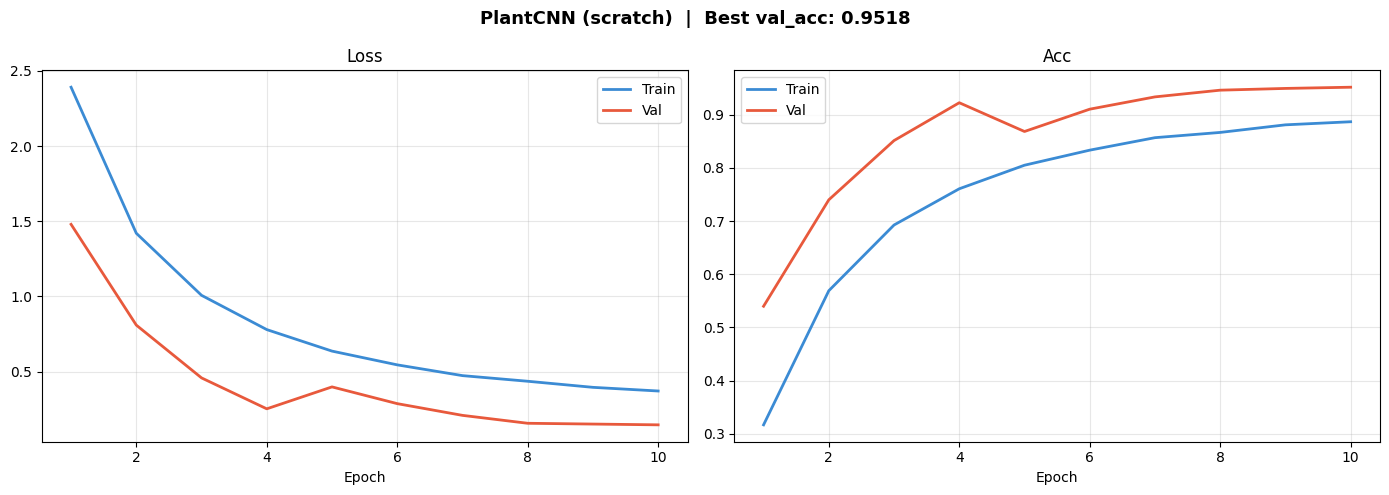

 Saved: plant_cnn_best.pth


In [14]:
plot_history(cnn_history, "PlantCNN (scratch)", cnn_best)
torch.save(cnn.state_dict(), "/kaggle/working/plant_cnn_best.pth")
print(f" Saved: plant_cnn_best.pth")

In [15]:
eff = models.efficientnet_b0(weights="DEFAULT")
in_features = eff.classifier[1].in_features
eff.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, NUM_CLASSES),
)
eff = eff.to(DEVICE)

# Замораживаем backbone
for name, param in eff.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False

trainable = sum(p.numel() for p in eff.parameters()
                if p.requires_grad)
total     = sum(p.numel() for p in eff.parameters())
print(f" EfficientNet-B0")
print(f"   Total    : {total:,}")
print(f"   Trainable: {trainable:,} (head only)")

criterion  = nn.CrossEntropyLoss(weight=class_weights)
optimizer  = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, eff.parameters()),
    lr=1e-3, weight_decay=1e-4
)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=10, eta_min=1e-6)

print("\n Phase 1: training head only...")
eff_history_p1, eff_best_p1, eff_metrics_p1 = train_model(
    eff, dataloaders, criterion, optimizer,
    scheduler, num_epochs=10, model_name="EfficientNet_Phase1"
)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 193MB/s]

 EfficientNet-B0
   Total    : 4,682,914
   Trainable: 675,366 (head only)

 Phase 1: training head only...


  train:   0%|          | 0/1099 [00:00<?, ?it/s]

  val  :   0%|          | 0/248 [00:00<?, ?it/s]

...

  val  :   0%|          | 0/248 [00:00<?, ?it/s]

Epoch [ 9/10] | Train loss: 0.2620 acc: 0.9135 | Val loss: 0.0915 acc: 0.9692 | lr: 2.54e-05 | 383.0s | total: 57.6m 


  train:   0%|          | 0/1099 [00:00<?, ?it/s]

  val  :   0%|          | 0/248 [00:00<?, ?it/s]

Epoch [10/10] | Train loss: 0.2643 acc: 0.9130 | Val loss: 0.0887 acc: 0.9708 | lr: 1.00e-06 | 375.6s | total: 63.8m 
  EfficientNet_Phase1
  Accuracy  : 0.9724  █████████████████████████████
  F1-score  : 0.9722
  Precision : 0.9729
  Recall    : 0.9724
  Val Loss  : 0.0870
  Time      : 63.8 min (3830s)
  Epochs    : 10/10


In [16]:
# Размораживаем весь backbone
for param in eff.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in eff.parameters()
                if p.requires_grad)
print(f" Full unfreeze — trainable: {trainable:,}")

optimizer2 = torch.optim.AdamW(
    eff.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer2, T_max=15, eta_min=1e-6)
print("\n Phase 2: fine-tuning full model...")
eff_history_p2, eff_best_p2, eff_metrics_p2 = train_model(
    eff, dataloaders, criterion, optimizer2,
    scheduler2, num_epochs=10, model_name="EfficientNet_Phase2"
)

 Full unfreeze — trainable: 4,682,914

 Phase 2: fine-tuning full model...


  train:   0%|          | 0/1099 [00:00<?, ?it/s]

  val  :   0%|          | 0/248 [00:00<?, ?it/s]

Epoch [ 1/10] | Train loss: 0.1220 acc: 0.9596 | Val loss: 0.0237 acc: 0.9916 | lr: 9.89e-05 | 431.4s | total: 7.2m 


  train:   0%|          | 0/1099 [00:00<?, ?it/s]

...

  val  :   0%|          | 0/248 [00:00<?, ?it/s]

Epoch [ 9/10] | Train loss: 0.0134 acc: 0.9954 | Val loss: 0.0046 acc: 0.9985 | lr: 3.52e-05 | 435.0s | total: 65.1m 


  train:   0%|          | 0/1099 [00:00<?, ?it/s]

  val  :   0%|          | 0/248 [00:00<?, ?it/s]

Epoch [10/10] | Train loss: 0.0103 acc: 0.9967 | Val loss: 0.0051 acc: 0.9985 | lr: 2.58e-05 | 425.6s | total: 72.2m 
  EfficientNet_Phase2
  Accuracy  : 0.9985  █████████████████████████████
  F1-score  : 0.9985
  Precision : 0.9986
  Recall    : 0.9985
  Val Loss  : 0.0046
  Time      : 72.2 min (4335s)
  Epochs    : 10/10


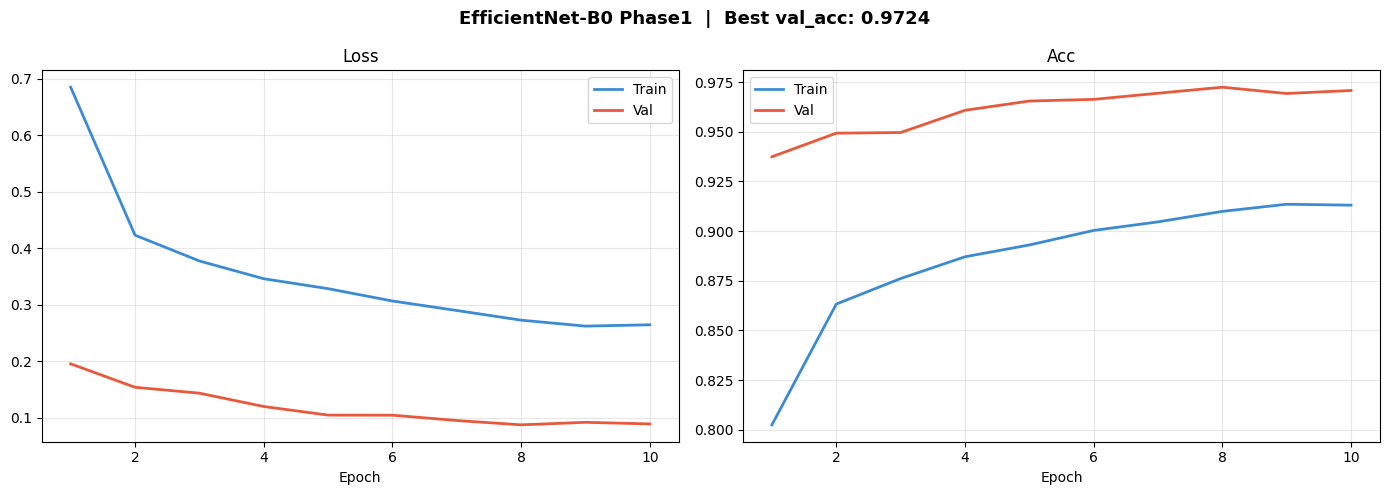

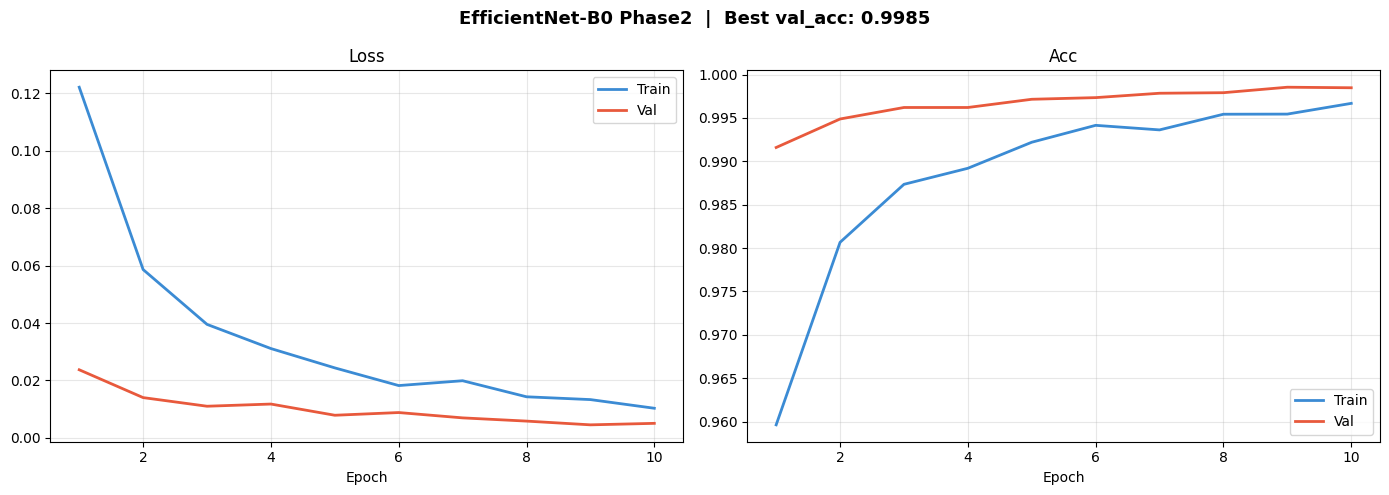

 Saved: efficientnet_b0_best.pth


In [17]:
plot_history(eff_history_p1, "EfficientNet-B0 Phase1", eff_best_p1)
plot_history(eff_history_p2, "EfficientNet-B0 Phase2", eff_best_p2)

torch.save(eff.state_dict(),
           "/kaggle/working/efficientnet_b0_best.pth")
print(f" Saved: efficientnet_b0_best.pth")

In [ ]:

print("  ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ")


all_results = {
    "PlantCNN (scratch)"  : cnn_metrics,
    "EfficientNet Phase1" : eff_metrics_p1,
    "EfficientNet Phase2" : eff_metrics_p2,
}

best_acc_val = max(m["acc"] for m in all_results.values())

for name, m in sorted(all_results.items(),
                       key=lambda x: x[1]["acc"],
                       reverse=True):
    bar  = "█" * int(m["acc"] * 30)
    mark = " " if m["acc"] == best_acc_val else "  "
    print(f"\n{mark} {name}")
    print(f"  Accuracy  : {m['acc']:.4f}  {bar}")
    print(f"  F1-score  : {m['f1']:.4f}")
    print(f"  Precision : {m['precision']:.4f}")
    print(f"  Recall    : {m['recall']:.4f}")
    print(f"  Val Loss  : {m['loss']:.4f}")
    print(f"  Time      : {m['time']/60:.1f} min")
    

best_name = max(all_results, key=lambda x: all_results[x]["acc"])
best_m    = all_results[best_name]
print(f"\n Победитель : {best_name}")
print(f"   Accuracy   : {best_m['acc']:.4f} "
      f"({best_m['acc']*100:.2f}%)")
print(f"   F1-score   : {best_m['f1']:.4f}")
print(f"   Time       : {best_m['time']/60:.1f} min")
print(f"\n→ Скачиваем efficientnet_b0_best.pth и деплоим")